# Exploratory Analysis of Academic, Behavioral, and Social Factors Associated with Student Performance

This project is investigating the academic, behavioral and social factors that are associated with student performance. This analysis is hoping to indentify the relationships between prior grades, study habits, alcohol consumption, family background, support and how that affects final academic grades. 

* How strongly does prior academic grades predict the student's final performance? 
* Does increased study time improve student performance?
* How does alcohol consumption and social activity affect student performance? Is there a negative relationship as assumed by the public?
* What role does family background and educational support play in a student's academic performance?
* Which variables demonstrate the strongest overall associations with final academic performance?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display settings
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data/student-mat.csv", sep=";")

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape:
(395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [12]:
categorical_features = df.select_dtypes(include=["object", "str"]).columns.tolist()

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumeric Features:")
print(numeric_features)

Categorical Features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numeric Features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Duplicate Rows:
0


In [13]:
df["total_alcohol"] = df["Dalc"] + df["Walc"]
df["parent_edu_avg"] = (
    df["Medu"] + df["Fedu"]
) / 2

# 
df["prior_grade_avg"] = (
    df["G1"] + df["G2"]
) / 2

# Target Variable Analysis (G3)

The target variable for this analysis is `G3`, which represents the student's final grade in the course on a scale from 0 to 20.

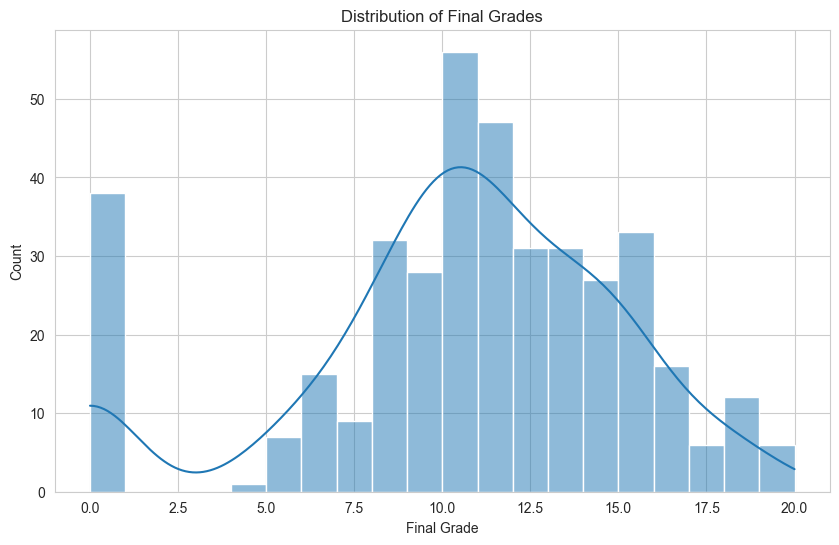

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Count")

plt.show()

There seems to be a normal distribution of final grades. There is a large cluster of students who performed at the middle range of scores meaning that there are fewer students who did exceptionally well and exceptionally poorly (excluding the failures at 0). The group of students studied in this dataset seem to represent a fairly balanced group of academic students. This could suggest that there are multiple factors which can affect a student's final grades rather than a single one. The large spike of zeroes could also suggest that certain variables could hevaily influence total failure or dropping out.

In [14]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

## Academic Factors

This section explores academic related variables such as prior grades, study habits/duration, failures and attendance-related behavior relates to a student's final academic performance.

### Progression of Grades

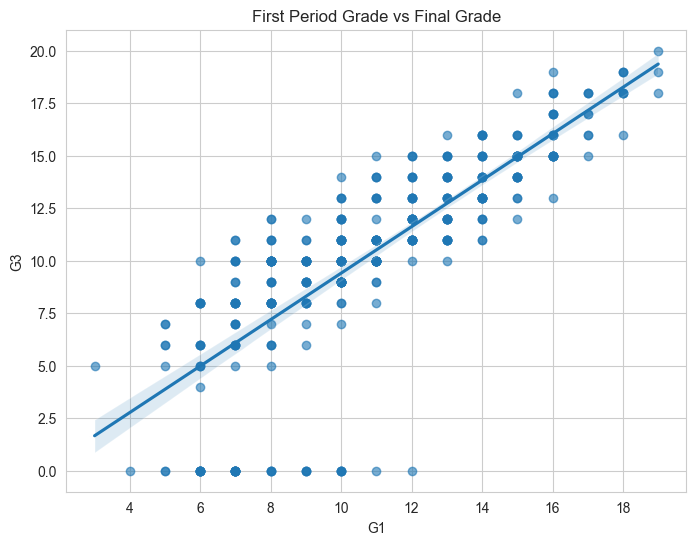

In [16]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="G1",
    y="G3",
    scatter_kws={"alpha": 0.6}
)

plt.title("First Period Grade vs Final Grade")
plt.xlabel("G1")
plt.ylabel("G3")

plt.show()

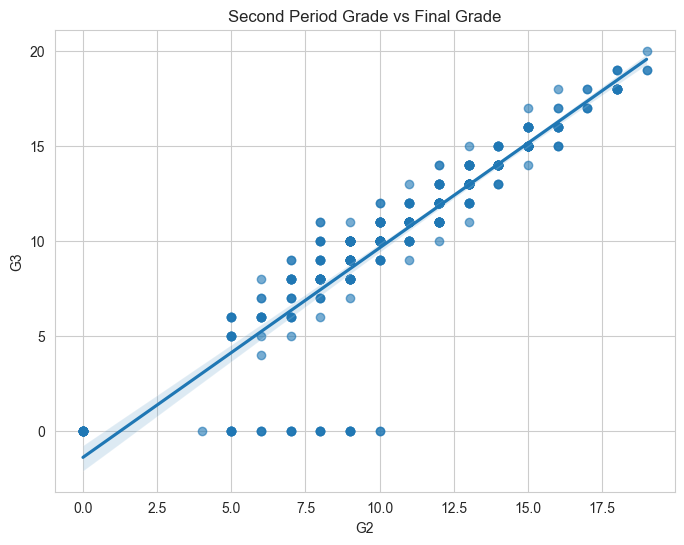

In [17]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="G2",
    y="G3",
    scatter_kws={"alpha": 0.6}
)

plt.title("Second Period Grade vs Final Grade")
plt.xlabel("G2")
plt.ylabel("G3")

plt.show()

There is a strong positive correlation between the previous grade of a student to their final grades. This suggests that using a student's previous scores, we could assume that the higher they did previously that the higher they would finish and also vice versa. 

### Study Time

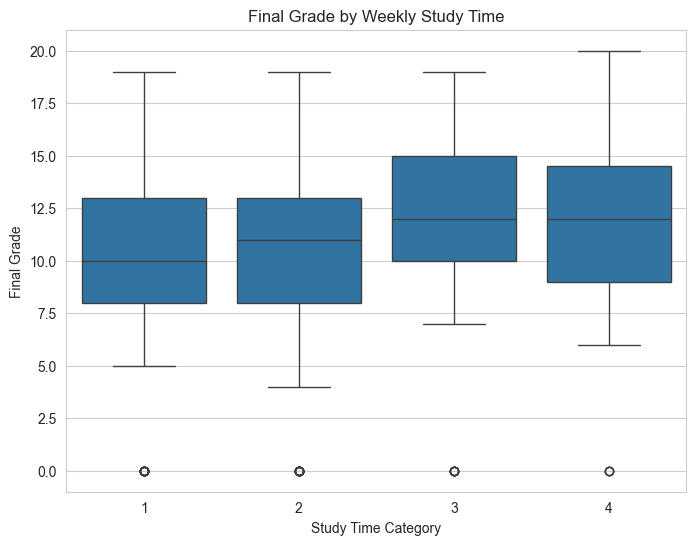

In [44]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title("Final Grade by Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")

plt.show()

In [45]:
df.groupby("studytime")["G3"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
studytime,,,,
1,10.047619,10.0,4.956311,105
2,10.171717,11.0,4.217537,198
3,11.400000,12.0,4.639504,65
4,11.259259,12.0,5.281263,27


Students with higher study time categories generally appear to achieve slightly higher final grades. However, substantial overlap exists between groups, indicating that study time alone does not fully determine academic performance.


### Past Failures

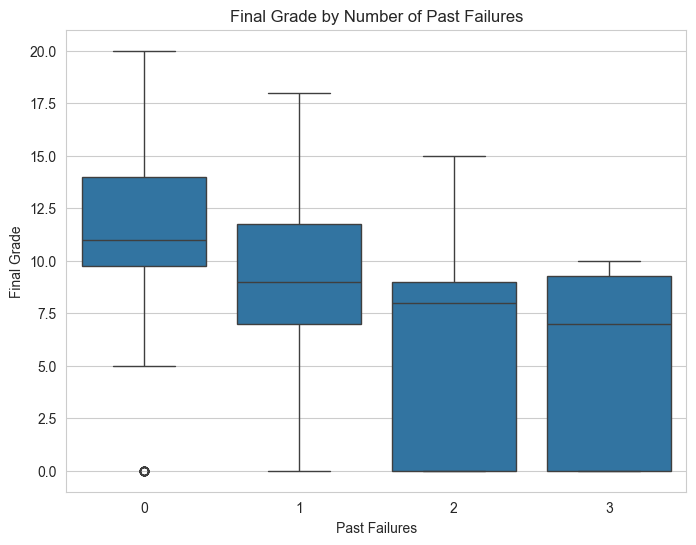

In [46]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="failures",
    y="G3"
)

plt.title("Final Grade by Number of Past Failures")
plt.xlabel("Past Failures")
plt.ylabel("Final Grade")

plt.show()

Past academic failures demonstrate a strong negative relationship with final grades. Students with a higher number of prior failures generally achieved substantially lower final grades. This along with the previous analysis done between G1/G3 and G2/G3 could suggest that there is a strong relationship between previous academic results and the final result.

### Abscences

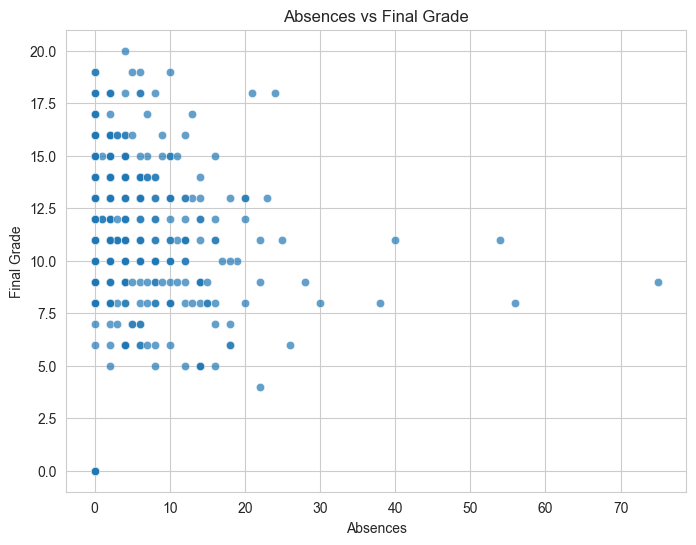

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3",
    alpha=0.7
)

plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")

plt.show()

Absences show a weak to moderate negative relationship with final grades. While students with very high absence counts often achieved lower academic outcomes, there is still considerable variation among students with similar absence levels. The relationship here is not nearly as strong as the relationship between prior academic results and the target G3 variable.

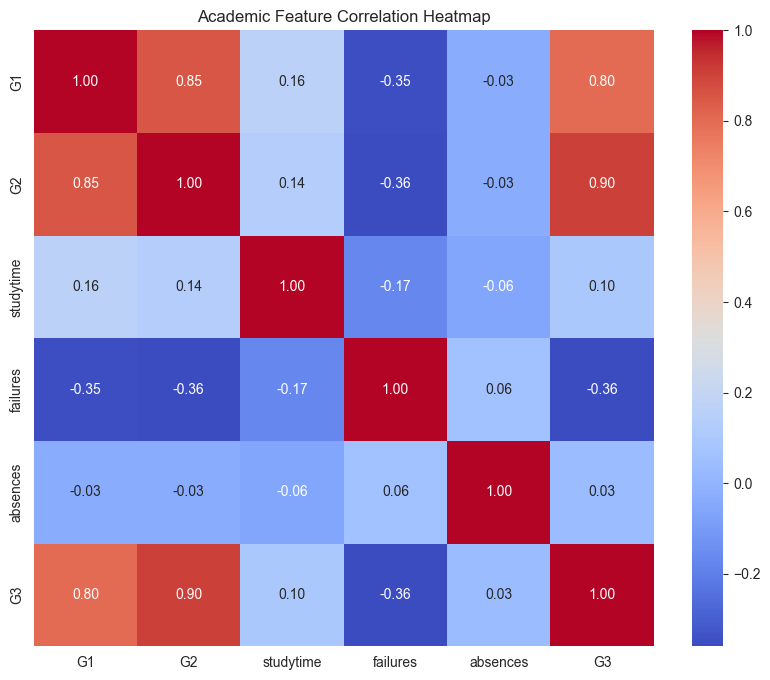

In [78]:
academic_features = [
    "G1",
    "G2",
    "studytime",
    "failures",
    "absences",
    "G3"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[academic_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Academic Feature Correlation Heatmap")

plt.show()

The academic correlation heatmap confirms that prior academic grades (`G1` and `G2`) demonstrate the strongest positive relationships with final grades (`G3`). In contrast, variables such as study time and absences show weaker associations. This reaffirms the previous statement that prior academic results seems to be a strong indicator for future academic results.

## Behavioral & Lifestyle

This section explores how behavioral and lifestyle related variables such as alcohol consumption, social outing frequency, free time and romantic relationship status relates to a student's final academic performance.

### Alcohol Consumption

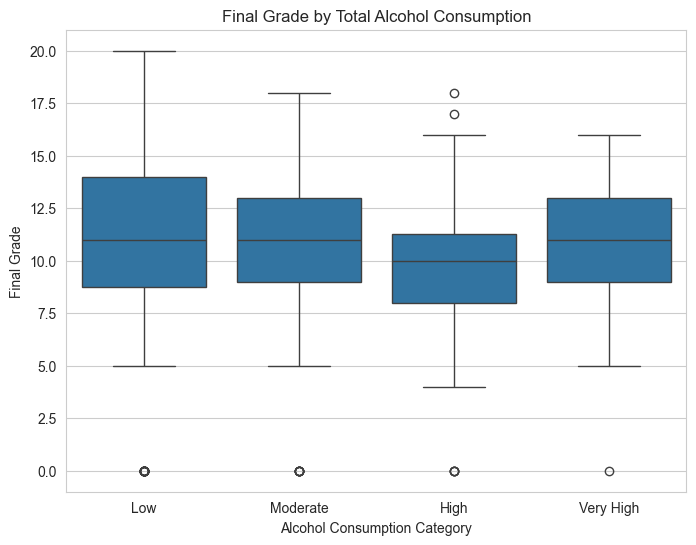

In [51]:
df["alcohol_category"] = pd.cut(
    df["total_alcohol"],
    bins=[1, 3, 5, 7, 10],
    labels=["Low", "Moderate", "High", "Very High"]
)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="alcohol_category",
    y="G3"
)

plt.title("Final Grade by Total Alcohol Consumption")
plt.xlabel("Alcohol Consumption Category")
plt.ylabel("Final Grade")

plt.show()

When combining workday and weekend alcohol consumption into a single measure, students with lower overall alcohol consumption generally appear to achieve slightly higher academic outcomes. These results suggest that higher alcohol consumption may lead to lower academic results.

### Social Outing Frequency

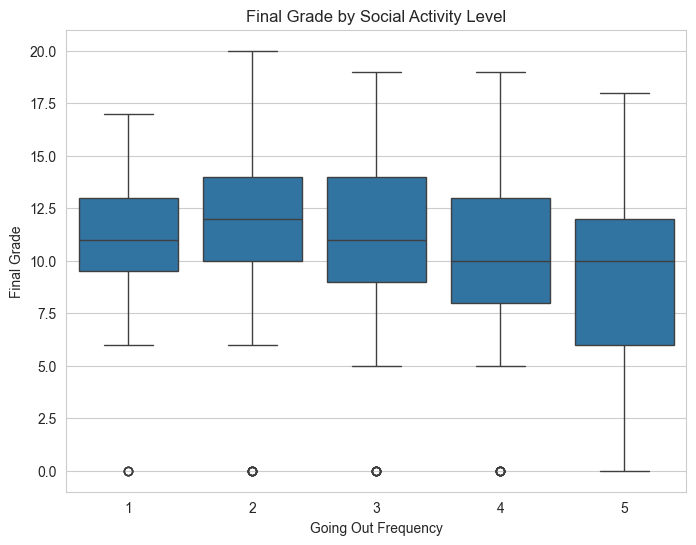

In [52]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="goout",
    y="G3"
)

plt.title("Final Grade by Social Activity Level")
plt.xlabel("Going Out Frequency")
plt.ylabel("Final Grade")

plt.show()

Students with very high levels of social activity tend to demonstrate slightly lower academic performance on average. However, the overlap between groups remains substantial, indicating that social activity alone is not a dominant predictor of academic success.

Moderate levels of social activity do not appear strongly harmful to the overall academic results of the student. This observation could actually lead to another discussion around balancing social interactions and academics. 

### Free Time

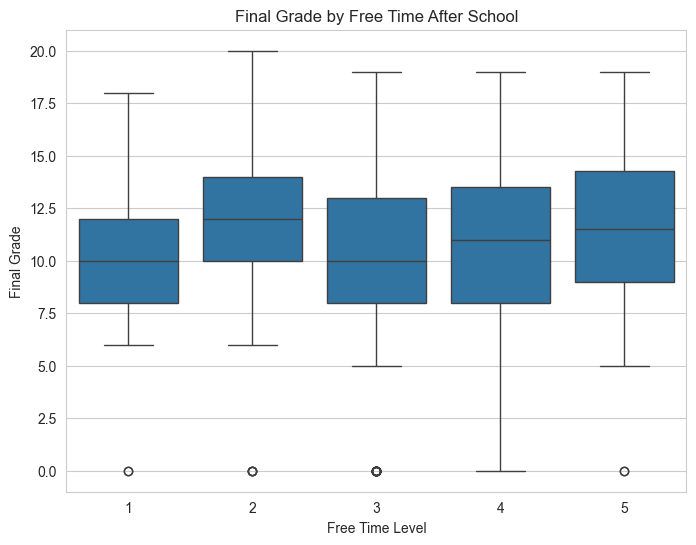

In [53]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="freetime",
    y="G3"
)

plt.title("Final Grade by Free Time After School")
plt.xlabel("Free Time Level")
plt.ylabel("Final Grade")

plt.show()

The relationship between free time and academic performance appears relatively weak. Students with extremely high free time levels may demonstrate slightly lower performance, although differences between groups are modest overall.

This suggests that free time alone does not strongly determine academic outcomes and may interact with other behavioral and academic factors.

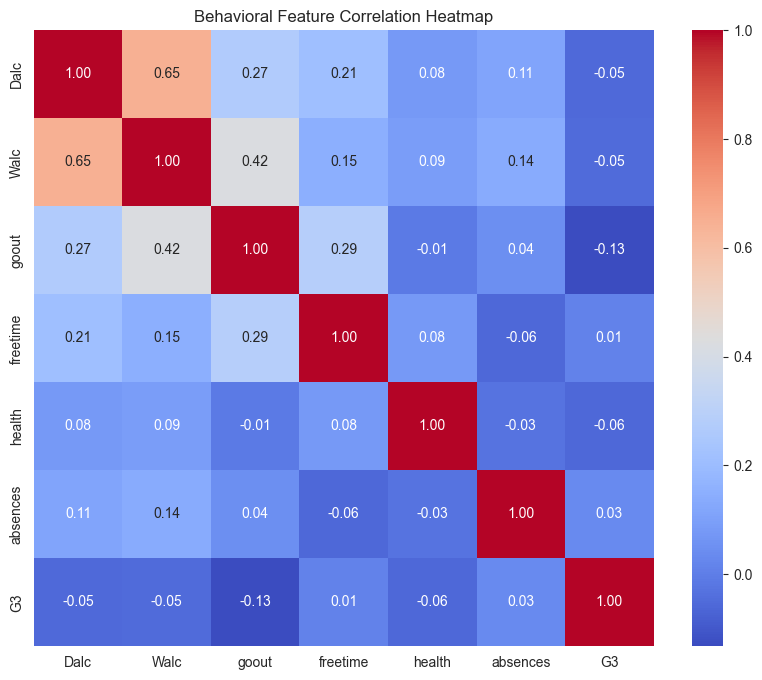

In [55]:
behavioral_features = [
    "Dalc",
    "Walc",
    "goout",
    "freetime",
    "health",
    "absences",
    "G3"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[behavioral_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Behavioral Feature Correlation Heatmap")

plt.show()

The behavioral correlation heatmap shows that most behavioral variables demonstrate relatively weak individual relationships with final academic performance (`G3`). Variables such as alcohol consumption and social activity tend to show slight negative associations with grades, although the relationships are considerably weaker than those observed for academic variables.

These findings suggest that behavioral and lifestyle factors may contribute to academic outcomes, but likely interact with broader academic and social influences rather than independently determining performance.

## Family & Social Support

This section explores how family and social suppport relates to a student's final academic performance.

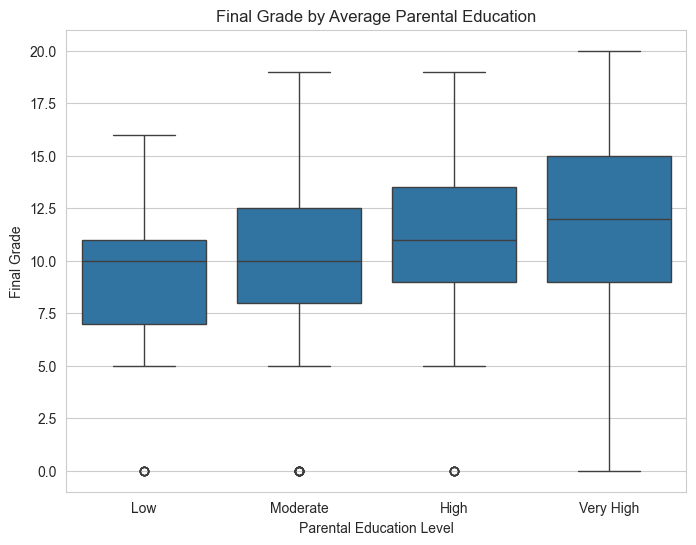

In [57]:
df["parent_edu_category"] = pd.cut(
    df["parent_edu_avg"],
    bins=[-1, 1, 2, 3, 4],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="parent_edu_category",
    y="G3"
)

plt.title("Final Grade by Average Parental Education")
plt.xlabel("Parental Education Level")
plt.ylabel("Final Grade")

plt.show()

Students with higher average parental education levels generally demonstrate somewhat stronger academic performance. There is still quite a large range of academic results (G3) that exists within each level of parental education, this suggests that there is other factors that are affecting the final grade result. 

### School Support

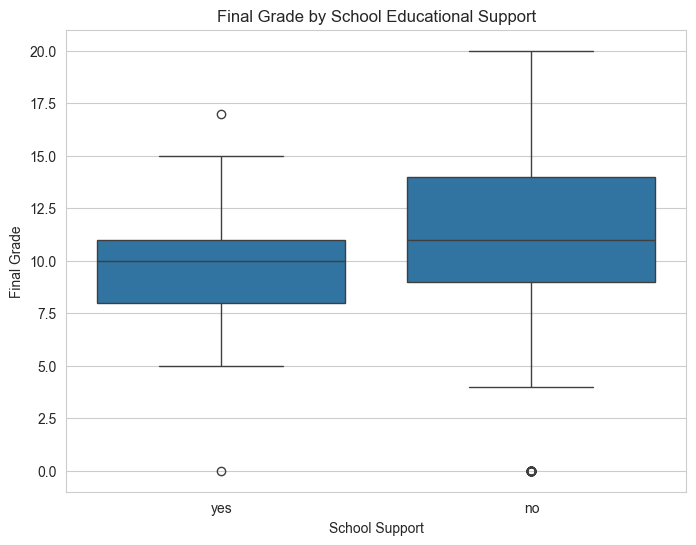

In [58]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="schoolsup",
    y="G3"
)

plt.title("Final Grade by School Educational Support")
plt.xlabel("School Support")
plt.ylabel("Final Grade")

plt.show()

Students receiving additional school educational support often appear to achieve somewhat lower final grades on average. However, this should not be interpreted as evidence that support harms academic performance. At first glance this may seem confusing but after thinking about it, it could be more that students who seek educational support or are placed in educational support programs are already performing at a lower level. That would skew the data in favor of lower scores for students gettign educational support by their school.

### Family Support

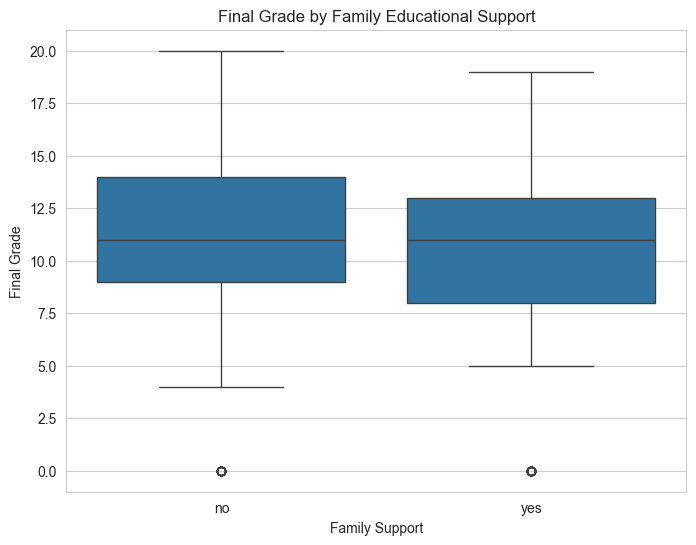

In [59]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="famsup",
    y="G3"
)

plt.title("Final Grade by Family Educational Support")
plt.xlabel("Family Support")
plt.ylabel("Final Grade")

plt.show()

Family educational support shows only a modest relationship with academic performance. Students receiving family support tend to have slightly higher median grades, although the difference between groups is small.

### Internet Access

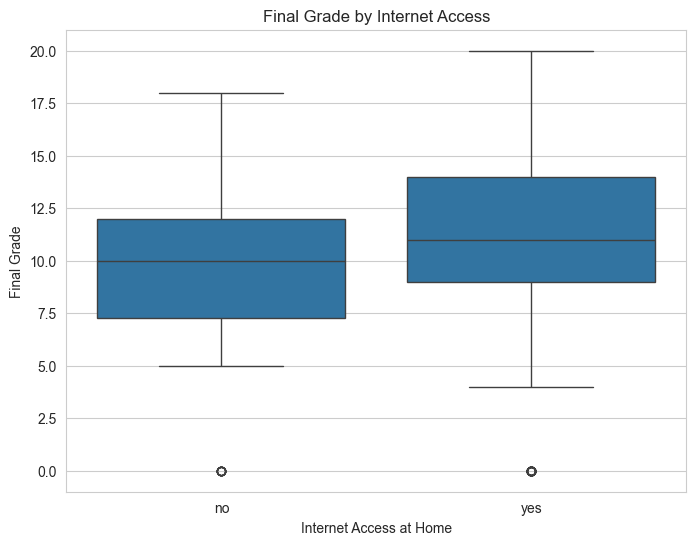

In [61]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="internet",
    y="G3"
)

plt.title("Final Grade by Internet Access")
plt.xlabel("Internet Access at Home")
plt.ylabel("Final Grade")

plt.show()

Students with internet access at home generally appear to perform slightly better academically. There is a relatively strong relationship between internet access and higher grades. 

### Education Aspirations

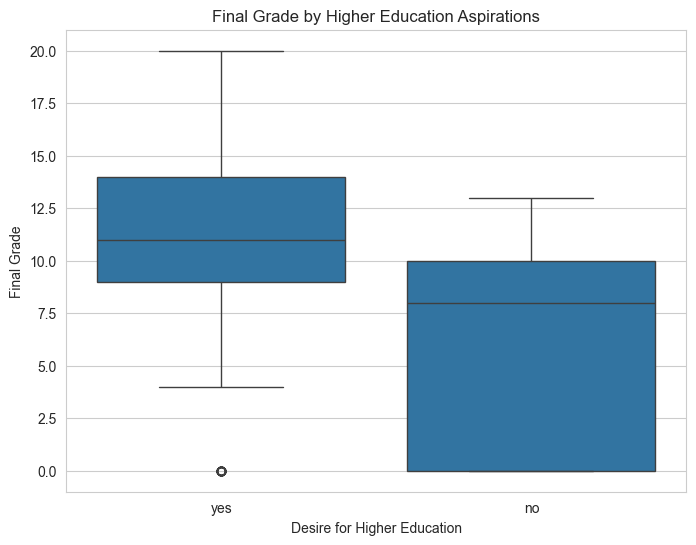

In [62]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="higher",
    y="G3"
)

plt.title("Final Grade by Higher Education Aspirations")
plt.xlabel("Desire for Higher Education")
plt.ylabel("Final Grade")

plt.show()

Students who expressed a desire to pursue higher education generally achieved substantially stronger academic outcomes than students who did not.

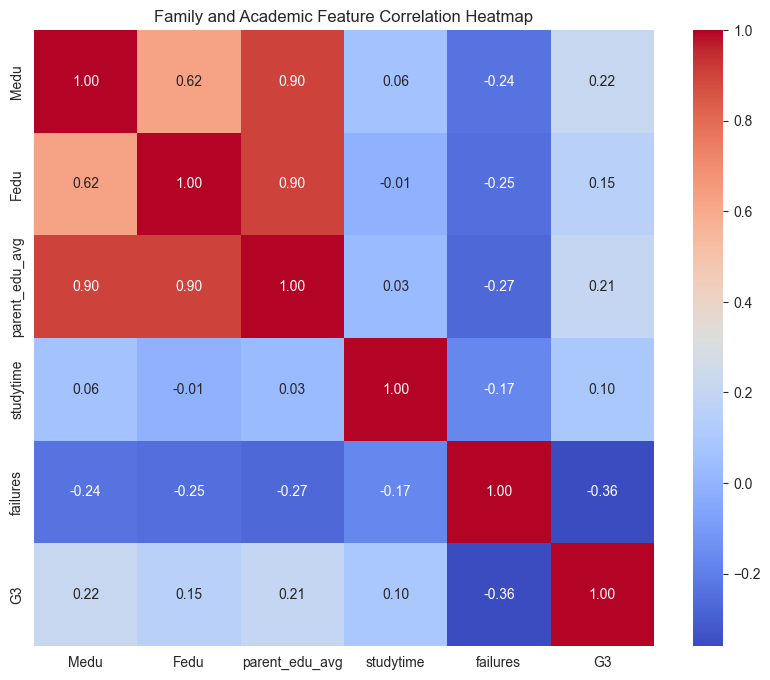

In [83]:
family_features = [
    "Medu",
    "Fedu",
    "parent_edu_avg",
    "studytime",
    "failures",
    "G3"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[family_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Family and Academic Feature Correlation Heatmap")

plt.show()

The family and social correlation heatmap shows that parental education variables demonstrate moderate positive relationships with academic performance. Meanwhile, variables such as family relationship quality show weaker associations.

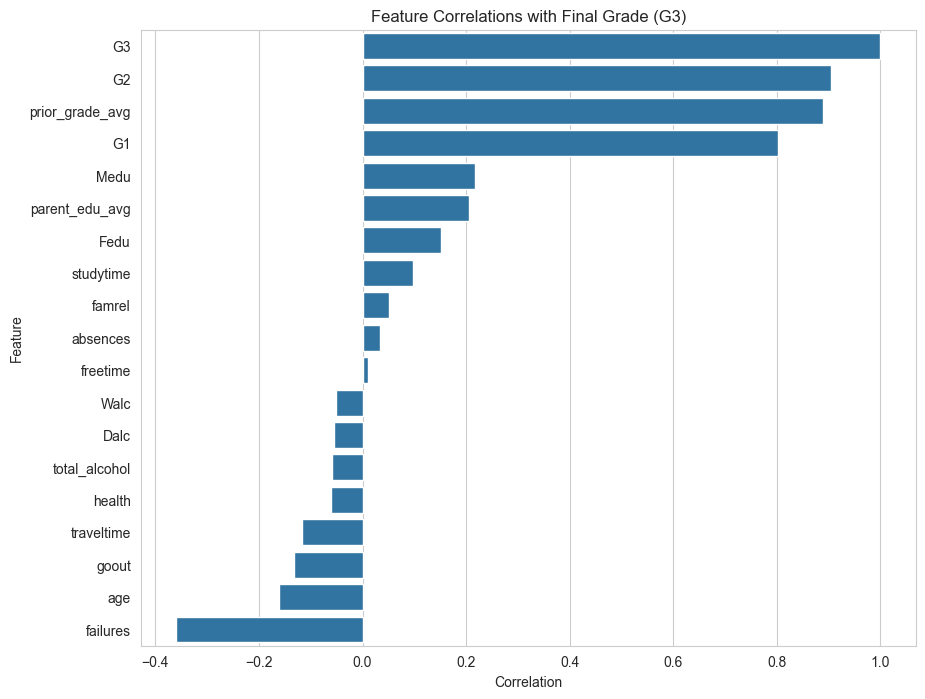

In [65]:
g3_corr = numeric_df.corr()["G3"].sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    x=g3_corr.values,
    y=g3_corr.index
)

plt.title("Feature Correlations with Final Grade (G3)")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

The correlation analysis confirms that `G2` and `G1` are the strongest positive predictors of final academic performance. These variables exhibit substantially stronger relationships with `G3` than any behavioral or demographic variable in the dataset.

Among non-grade variables, past failures demonstrate one of the strongest negative relationships with final grades, while variables such as study time and parental education show weaker but still observable positive associations.

Most behavioral variables, including freetime and social activity, exhibit somewhat weak correlations with final performance.

## Linear Regression Analysis

To further quantify relationships identified during exploratory analysis, linear regression was used to model the relationship between academic variables and final student performance (`G3`).

Both simple linear regression and multiple linear regression were used to evaluate how strongly selected variables predict final academic outcomes.

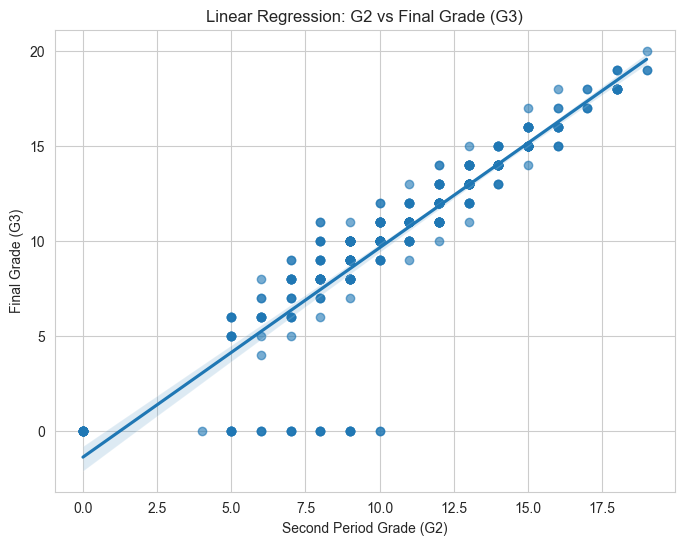

In [84]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="G2",
    y="G3",
    scatter_kws={"alpha": 0.6}
)

plt.title("Linear Regression: G2 vs Final Grade (G3)")
plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")

plt.show()

In [93]:
import statsmodels.api as sm
X = df["G2"]
y = df["G3"]

X = sm.add_constant(X)

simple_model = sm.OLS(y, X).fit()

print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     1776.
Date:                Mon, 11 May 2026   Prob (F-statistic):          7.63e-148
Time:                        23:31:03   Log-Likelihood:                -823.83
No. Observations:                 395   AIC:                             1652.
Df Residuals:                     393   BIC:                             1660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3928      0.297     -4.690      0.0

The simple linear regression model demonstrates a very strong relationship between second-period grades (`G2`) and final grades (`G3`).

The regression coefficient for `G2` is positive, indicating that higher second-period grades are associated with higher final academic performance. Additionally, the p-value for `G2` is extremely small, suggesting that the relationship is statistically significant.

The model also produces a high R² value, indicating that a substantial proportion of the variation in final grades can be explained by second-period academic performance alone.

In [92]:
features = [
    "G1",
    "G2",
    "studytime",
    "failures",
    "total_alcohol",
    "goout"
]

X_multi = df[features]
y_multi = df["G3"]

X_multi = sm.add_constant(X_multi)

multi_model = sm.OLS(
    y_multi,
    X_multi
).fit()

print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     305.2
Date:                Mon, 11 May 2026   Prob (F-statistic):          1.53e-143
Time:                        23:30:53   Log-Likelihood:                -816.75
No. Observations:                 395   AIC:                             1647.
Df Residuals:                     388   BIC:                             1675.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.5627      0.556     -2.808

The multiple linear regression model evaluates the relationship between several academic and behavioral variables and final academic performance simultaneously.

The results indicate that prior academic grades (`G1` and `G2`) remain the strongest predictors of final performance, even after controlling for additional variables. In contrast, behavioral variables such as alcohol consumption and social activity demonstrate weaker effects and may become statistically insignificant when academic variables are included in the model.

These findings reinforce earlier exploratory analysis suggesting that historical academic achievement is the dominant factor associated with final student outcomes within this dataset.

## Research Question Answers

### Research Question 1
How strongly do prior academic grades predict final performance?

Prior academic grades (`G1` and `G2`) demonstrated extremely strong positive relationships with final grades (`G3`). Linear regression and correlation analysis both showed that earlier academic performance is the strongest overall predictor of final outcomes within the dataset.

---

### Research Question 2
Does increased study time improve student outcomes?

Students with higher study time levels generally achieved somewhat stronger academic outcomes on average. However, substantial overlap remained between study groups, suggesting that study time alone does not fully determine academic success.

---

### Research Question 3
Do alcohol consumption and social activity negatively affect academic performance?

Alcohol consumption and social activity demonstrated weak to moderate negative relationships with final grades. Students with very high levels of alcohol consumption or social activity tended to perform somewhat worse academically, although these effects were considerably weaker than academic variables.

---

### Research Question 4
Does family background and educational support influence grades?

Family and educational support variables demonstrated moderate relationships with student performance. Higher parental education levels and stronger higher education aspirations were associated with improved academic outcomes, suggesting that social and educational environments may contribute positively to student success.

---

### Research Question 5
Which variables demonstrate the strongest overall associations with final academic performance?

Prior academic performance variables (`G1` and `G2`) showed the strongest positive relationships with final grades, while past academic failures demonstrated one of the strongest negative relationships. Behavioral and social variables generally showed weaker independent associations with student performance.

## Limitations

Several limitations should be considered when interpreting the results of this analysis.

First, the dataset is observational rather than experimental, meaning that the analysis can identify associations between variables but cannot establish causal relationships. For example, although alcohol consumption and study time are associated with academic performance, the analysis cannot determine whether these factors directly cause changes in student outcomes.

Second, many variables within the dataset are self-reported by students. Self-reported behavioral measures such as alcohol consumption, study time, and social activity may contain reporting bias or inaccuracies.

Third, the dataset represents students from Portuguese secondary schools and may not generalize to broader student populations, different educational systems, or different cultural environments.

Additionally, some important factors that may influence academic performance are not included in the dataset, such as detailed socioeconomic information, mental health variables, classroom quality, or individual learning differences.